# Задание № 1:
1. Загрузить последовательность отсчетов из файла «lab_3_z1.bin».
Формат записи данных в файле — бинарный, integer16 (int16, 2 байта на отсчет); частота
дискретизации 1 кГц.
2. Изобразить загруженную последовательность на графике.
3. Выполнить текущее усреднение (moving average или running mean) последовательности по
окну с эквивалентной длительностью 10 секунд.
4. Изобразить результат усреднения на графике на графике.

Дополнительное задание [+2 балла]: 
*произвести детрендирование данных.*

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
data = np.fromfile(".\\data\\var08_z1.bin", dtype=np.int16)
time = np.arange(len(data)) / 1000

len(data)

1800000

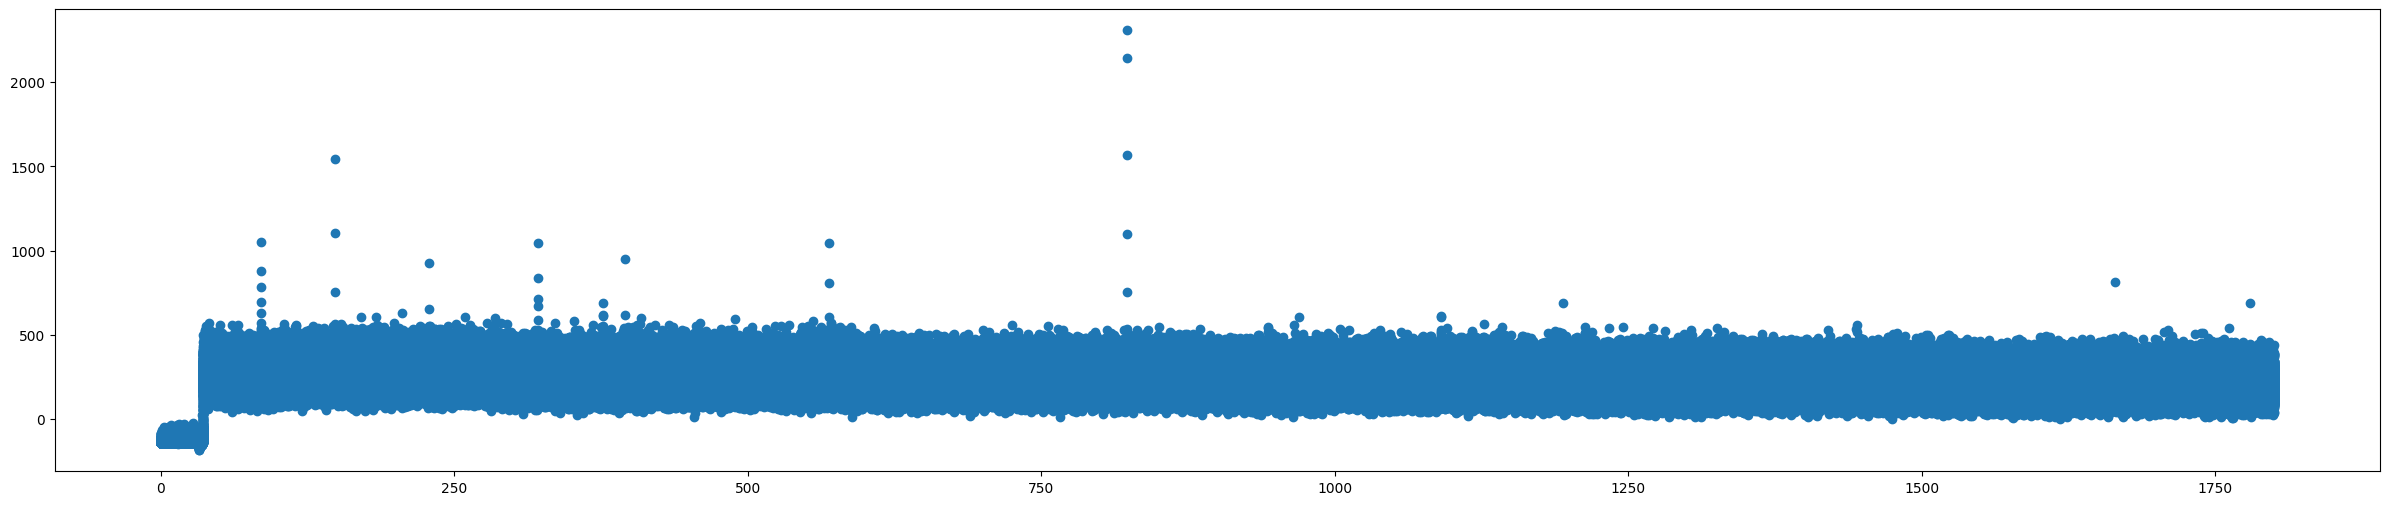

In [18]:
plt.figure(figsize=(30, 6))
plt.scatter(time, data)

In [19]:
window = 10 * 1000 # ширина окна 10 секунд

move_data = []

step = 0
time_s = 0
time_f = time_s + window

for i in range(window // 2, len(data) - window // 2):
    elem = data[i - window // 2: i + window // 2 - 1]
    move_data.append(np.average(elem))

        

In [33]:
H = 250 * 1000 # шаг 250 секунд

move_time = time[window // 2: - window // 2]

X_p = [time[ind * H] for ind in range(1, len(time) // H + 1)]
Y_p = [move_data[round(X_p[ind] * 1000)] for ind in range(len(X_p))]

Y_p, X_p, move_time[-1]

([np.float64(273.5325532553255),
  np.float64(254.77327732773279),
  np.float64(242.15141514151415),
  np.float64(233.35433543354335),
  np.float64(219.996699669967),
  np.float64(213.009200920092),
  np.float64(205.2005200520052)],
 [np.float64(250.0),
  np.float64(500.0),
  np.float64(750.0),
  np.float64(1000.0),
  np.float64(1250.0),
  np.float64(1500.0),
  np.float64(1750.0)],
 np.float64(1794.999))

In [34]:
def MakeMatrix(n, m, value=0):
    res = []
    for i in range(n):
        res.append([])
        for j in range(m):
            res[i].append(value)
    return res

def MatrixMultiplication(A, B):
    result = MakeMatrix(len(A), len(B[0])) 
    #print(result)
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(A[0])):
                result[i][j] += A[i][k] * B[k][j]
    return result

In [35]:
def XMatrix(N_):
    X = np.zeros((N_ + 1, N_ + 1))
    
    for i in range(N_ + 1):
        for j in range(N_ + 1):
            elem = 0
            for k in range(len(X_p)):
                elem += X_p[k]**(i + j)
            X[i][j] = elem
    return X

In [36]:
def XYMatrix(N_):
    XY = np.zeros((N_ + 1, 1))
    
    for i in range(N_ + 1):
        for k in range(len(X_p)):
            XY[i][0] += Y_p[k] * X_p[k]**i
    return XY

In [37]:
n_ = len(Y_p)
N = 1

In [38]:
X_matr = XMatrix(N)

Y_matr = XYMatrix(N)

X_matr, Y_matr, len(X_matr)

(array([[7.00e+00, 7.00e+03],
        [7.00e+03, 8.75e+06]]),
 array([[   1642.0180018 ],
        [1564348.25982598]]),
 2)

In [39]:
polinom_coeff = np.linalg.solve(X_matr , Y_matr)
polinom_coeff

array([[ 2.78956710e+02],
       [-4.43827097e-02]])

In [40]:
x_p = np.linspace(move_time[0], move_time[-1], len(move_time))
y_p = [0] * len(x_p)

for i in range(len(x_p)):
    for n in range(N + 1):
        y_p[i] += polinom_coeff[n][0] * x_p[i]**n

    

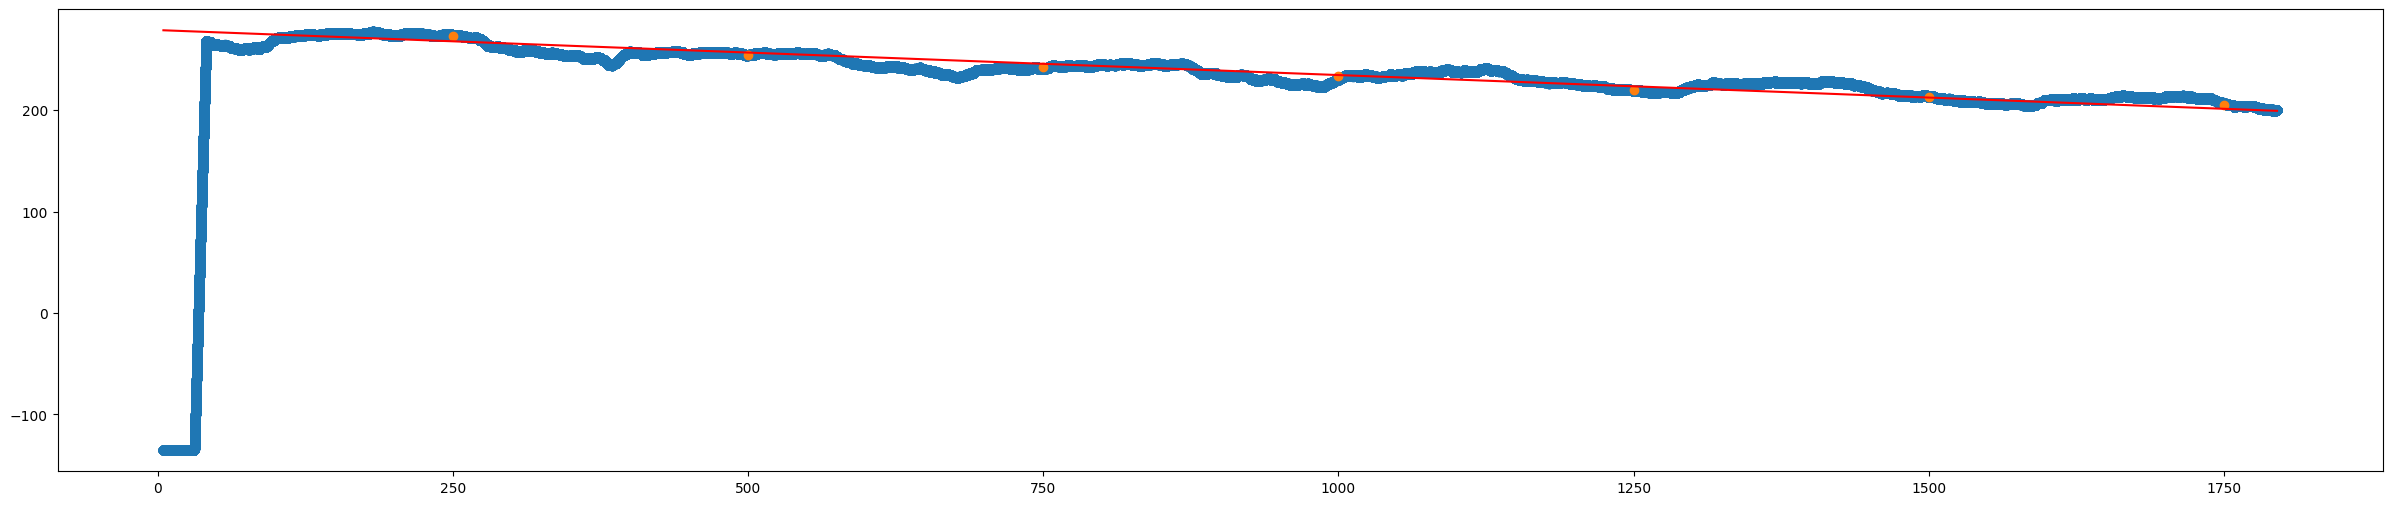

In [43]:
plt.figure(figsize=(30, 6))

plt.scatter(move_time, move_data)
plt.scatter(X_p, Y_p)
plt.plot(x_p, y_p, color='red')

In [44]:
determ_data = [move_data[ind] - y_p[ind] for ind in range(len(move_data))]

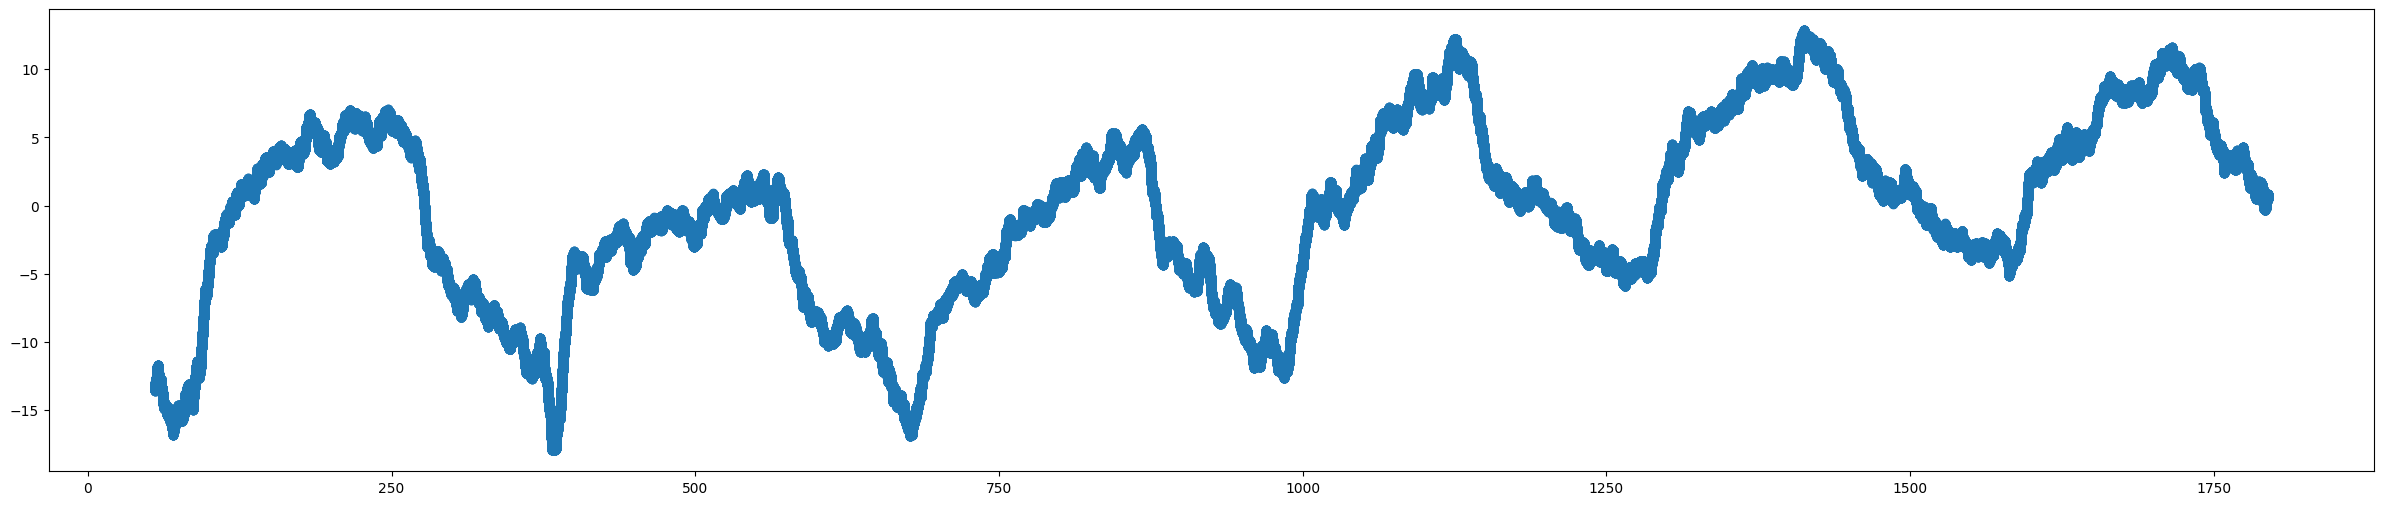

In [46]:
plt.figure(figsize=(30, 6))

plt.scatter(move_time[50000:], determ_data[50000:])
# plt.scatter(X_p, Y_p)
# plt.plot(x_p, y_p, color='red')